# JYXFE: SVM from PCA
puente - Gustavo Cerati

## 1. Import PCA df

In [1]:
from pathlib import Path
import pandas as pd

input_path = Path(
    "/home/tperezsanchez/FoundationModel_EEG_Dissertation/Main_project/results/JYXFE/Feature_ext/Part2_features/JYXFE_IN-normalized_npz_FP-fullnpz_W10s_PRE6to5min_ICT0to1min_GAPasINT_FINAL-PREvsSEIZ_20260511_v01_FEAT-TIME-FREQ_20260511_v01/df_windows_JYXFEpca.pkl"
)

df_windows_pca = pd.read_pickle(input_path)

print("Loaded dataframe:")
print("Shape:", df_windows_pca.shape)

df_windows_pca.head()

Loaded dataframe:
Shape: (322, 18)


,file_name,window_id,start_sample,end_sample,fs,n_channels,window_sec,seizure_onsets,window_start_time,window_end_time,class_label,label_name,excluded_reason,PC1,PC2,PC3,PC4,PC5
0,JYXFE_22_preproc_full.npz,983,2034810,2036880,207.031055,2,10,[2021-05-04 20:33:31.000000],2021-05-04 20:27:26.525499679,2021-05-04 20:27:36.523999679,1,preictal,None,-1.064052,1.294069,-0.460270,0.234506,-1.516932
1,JYXFE_22_preproc_full.npz,984,2036880,2038950,207.031055,2,10,[2021-05-04 20:33:31.000000],2021-05-04 20:27:36.523999679,2021-05-04 20:27:46.522499678,1,preictal,None,-0.073443,0.087551,0.021230,-0.016202,0.061701
2,JYXFE_22_preproc_full.npz,985,2038950,2041020,207.031055,2,10,[2021-05-04 20:33:31.000000],2021-05-04 20:27:46.522499678,2021-05-04 20:27:56.520999678,1,preictal,None,-2.117653,-0.646321,-0.576643,-0.112017,0.019424
3,JYXFE_22_preproc_full.npz,986,2041020,2043090,207.031055,2,10,[2021-05-04 20:33:31.000000],2021-05-04 20:27:56.520999678,2021-05-04 20:28:06.519499678,1,preictal,None,-1.882690,0.041619,-0.415088,-0.582671,-0.208340
4,JYXFE_22_preproc_full.npz,987,2043090,2045160,207.031055,2,10,[2021-05-04 20:33:31.000000],2021-05-04 20:28:06.519499678,2021-05-04 20:28:16.517999678,1,preictal,None,-1.701949,-0.809071,-0.416796,-0.764038,0.032930


## 2. Quality control

In [2]:
df_SVM = df_windows_pca.copy()
df_SVM["window_start_time"] = pd.to_datetime(df_SVM["window_start_time"])
df_SVM = df_SVM.sort_values("window_start_time").reset_index(drop=True)

In [3]:
print(df_SVM["window_start_time"].head())
print(df_SVM["window_start_time"].tail())
# it checks with mapping, as it is the last day of recording (2019-12-11)

0   2021-05-04 20:27:26.525499679
1   2021-05-04 20:27:36.523999679
2   2021-05-04 20:27:46.522499678
3   2021-05-04 20:27:56.520999678
4   2021-05-04 20:28:06.519499678
Name: window_start_time, dtype: datetime64[ns]
317   2022-04-13 12:31:43.109999589
318   2022-04-13 12:31:53.108499589
319   2022-04-13 12:32:03.106999588
320   2022-04-13 12:32:13.105499588
321   2022-04-13 12:32:23.103999588
Name: window_start_time, dtype: datetime64[ns]


In [4]:
df_SVM = df_SVM.dropna(axis=1, how="all").copy()

metadata_cols = [
    "window_id",
    "start_sample",
    "end_sample",
    "fs",
    "n_channels",
    "window_sec",
    "seizure_onsets",
    "file_name",
    "window_start_time",
    "window_end_time",
    "class_label",
    "label_name"
]

feature_cols = [col for col in df_SVM.columns if col not in metadata_cols]

X = df_SVM[feature_cols].copy()
y = df_SVM["class_label"].copy()

print("df_SVM shape:", df_SVM.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("NaNs in X:", X.isna().sum().sum())
print("Class counts:")
print(y.value_counts())

df_SVM shape: (322, 17)
X shape: (322, 5)
y shape: (322,)
NaNs in X: 0
Class counts:
class_label
1    161
2    161
Name: count, dtype: int64


This step prepares the dataset for SVM classification. Completely empty columns are removed, metadata and label columns are excluded from the model inputs, and the remaining columns are selected as features. The feature matrix X contains the variables used for prediction, while y contains the corresponding class labels. Basic sanity checks are then performed to verify the dataframe dimensions, detect missing values, and inspect the class distribution.

In [5]:
import numpy as np

# -------------------------------
# 1. Define target variable
# -------------------------------
y = df_SVM["class_label"].copy()

# -------------------------------
# 2. Drop metadata, identifiers, temporal info, target columns,
#    and columns that are not EEG-derived features
# -------------------------------
cols_to_drop = [
    "file_name",
    "window_id",
    "start_sample",
    "end_sample",
    "fs",
    "n_channels",
    "window_sec",
    "seizure_onsets",
    "window_start_time",
    "window_end_time",
    "class_label",
    "label_name",
    "excluded_reason"   # important: this column is completely empty
]

# Drop only columns that actually exist
cols_to_drop = [col for col in cols_to_drop if col in df_SVM.columns]

X = df_SVM.drop(columns=cols_to_drop).copy()

# -------------------------------
# 3. Keep only numeric EEG-derived features
# -------------------------------
X = X.select_dtypes(include=[np.number])

# -------------------------------
# 4. Replace infinite values with NaN
# -------------------------------
X = X.replace([np.inf, -np.inf], np.nan)

# -------------------------------
# 5. Keep only rows without missing values in EEG features
# -------------------------------
mask = X.notna().all(axis=1)

X = X.loc[mask].copy()
y = y.loc[mask].copy()

# -------------------------------
# 6. Remove constant columns
# -------------------------------
constant_cols = [col for col in X.columns if X[col].nunique() <= 1]
X = X.drop(columns=constant_cols)

# -------------------------------
# 7. Sanity checks
# -------------------------------
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Removed constant columns:", constant_cols)
print("Total NaNs in X:", X.isna().sum().sum())
print("Class counts:")
print(y.value_counts())

X shape: (322, 5)
y shape: (322,)
Removed constant columns: []
Total NaNs in X: 0
Class counts:
class_label
1    161
2    161
Name: count, dtype: int64


This step prepares the feature matrix for SVM classification. The target labels are extracted from the dataframe, while metadata, identifiers, temporal variables, and non-feature columns are removed from the input data. Only numeric EEG-derived features are retained. Infinite values are converted to missing values, and windows containing missing feature values are excluded to ensure compatibility with the SVM model. Constant columns are also removed because they do not contribute discriminative information. Finally, sanity checks are performed to verify the dimensions of the feature matrix and target vector, confirm the absence of missing values, and inspect the class distribution.

In [6]:
# Print final shapes
print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

# Print feature names used for SVM
print("Features used:")
print(X.columns.tolist())

Final X shape: (322, 5)
Final y shape: (322,)
Features used:
['PC1', 'PC2', 'PC3', 'PC4', 'PC5']


In [7]:
# Convert labels to binary format:
# 0 = preictal
# 1 = seizure
y_binary = y.map({
    1: 0,
    2: 1
})

print(y_binary.value_counts())
y = y_binary.copy()

class_label
0    161
1    161
Name: count, dtype: int64


In [8]:
# y.mean() corresponds to the proportion of class 1 (seizure)
global_ratio = y.mean()
print("Global seizure ratio:", global_ratio)

Global seizure ratio: 0.5


## 3. SPLIT

In [9]:
# Use the cleaned dataset size, not the original dataframe size
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

n = len(X)

ideal_train = 0.70
ideal_val = 0.15
ideal_test = 0.15

# Possible positions where training ends
train_candidates = range(
    int(0.70 * n),
    int(0.90 * n),
    max(1, n // 1000)
)

# Possible validation set sizes
val_candidates = range(
    int(0.05 * n),
    int(0.20 * n),
    max(1, n // 1000)
)

# Search for the best temporal split
best = None
best_score = np.inf

In [10]:
# This procedure creates a temporal split by preserving the chronological order
# of the samples, while selecting the train/validation/test boundaries that
# best match the desired split proportions and maintain class ratios close to
# the global dataset distribution.
for train_end in train_candidates:
    for val_size in val_candidates:
        val_end = train_end + val_size

        if val_end >= n:
            continue

        # temporal subsets because df is already sorted by window_start_time
        # SPLIT STARTS HERE
        y_train = y.iloc[:train_end]
        y_val = y.iloc[train_end:val_end]
        y_test = y.iloc[val_end:]

        # require both classes in every split
        # MAKE SURE OF THE PRESENCE OF EACH CLASS IN EVERY SET
        if y_train.nunique() < 2 or y_val.nunique() < 2 or y_test.nunique() < 2:
            continue

        # size closeness to 70/15/15
        # measure how close is to the ideal proportion
        train_frac = len(y_train) / n
        val_frac = len(y_val) / n
        test_frac = len(y_test) / n

        size_score = (
            abs(train_frac - 0.70) +
            abs(val_frac - 0.15) +
            abs(test_frac - 0.15)
        )

        # class ratio closeness to global ratio
        # measure how close is the preictal proportions 
        ratio_score = (
            abs(y_train.mean() - global_ratio) +
            abs(y_val.mean() - global_ratio) +
            abs(y_test.mean() - global_ratio)
        )

        # combined score for choosing the best score
        score = size_score + ratio_score * 3

        if score < best_score:
            best_score = score
            best = (train_end, val_end)


In [11]:
# Unpack the best split boundaries found previously
# train_end = index where the training set stops
# val_end = index where the validation set stops
train_end, val_end = best

# Create the training set:
# from the beginning of the dataset up to train_end (excluded)
X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

# Create the validation set:
# from train_end up to val_end (excluded)
X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

# Create the test set:
# from val_end to the end of the dataset
X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

In [12]:
print("\nSet sizes:")
print(f"Train: {len(X_train)} ({len(X_train)/n:.3%})")
print(f"Val:   {len(X_val)} ({len(X_val)/n:.3%})")
print(f"Test:  {len(X_test)} ({len(X_test)/n:.3%})")

print("\nPreictal ratios:")
print(f"Global: {y.mean():.5f}")
print(f"Train:  {y_train.mean():.5f}")
print(f"Val:    {y_val.mean():.5f}")
print(f"Test:   {y_test.mean():.5f}")

print("\nTime ranges:")
print("Train:", df_SVM.loc[0, "window_start_time"], "->", df_SVM.loc[train_end - 1, "window_start_time"])
print("Val:  ", df_SVM.loc[train_end, "window_start_time"], "->", df_SVM.loc[val_end - 1, "window_start_time"])
print("Test: ", df_SVM.loc[val_end, "window_start_time"], "->", df_SVM.loc[n - 1, "window_start_time"])


Set sizes:
Train: 225 (69.876%)
Val:   42 (13.043%)
Test:  55 (17.081%)

Preictal ratios:
Global: 0.50000
Train:  0.49778
Val:    0.50000
Test:   0.50909

Time ranges:
Train: 2021-05-04 20:27:26.525499679 -> 2021-08-08 21:16:33.600999913
Val:   2021-08-08 21:16:43.599499912 -> 2021-11-26 09:46:55.495499673
Test:  2021-11-26 09:47:05.493999672 -> 2022-04-13 12:32:23.103999588



Fold 1
Train class counts:
class_label
0    36
1    35
Name: count, dtype: int64
Validation class counts:
class_label
1    35
0    33
Name: count, dtype: int64

Fold 2
Train class counts:
class_label
1    70
0    69
Name: count, dtype: int64
Validation class counts:
class_label
1    35
0    33
Name: count, dtype: int64

Fold 3
Train class counts:
class_label
1    105
0    102
Name: count, dtype: int64
Validation class counts:
class_label
1    35
0    33
Name: count, dtype: int64

Fold 4
Train class counts:
class_label
1    140
0    135
Name: count, dtype: int64
Validation class counts:
class_label
1    35
0    33
Name: count, dtype: int64


## 4. Model training

In [13]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, balanced_accuracy_score

# -----------------------------
# Build the machine learning pipeline
# -----------------------------
# Step 1: Standardize the features so they have comparable scale
# Step 2: Train an SVM with RBF kernel
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", class_weight="balanced"))
])

# -----------------------------
# Define temporal cross-validation
# -----------------------------
# TimeSeriesSplit preserves chronological order inside the training set
tscv = TimeSeriesSplit(n_splits=4)

# -----------------------------
# Define the hyperparameter search space
# -----------------------------
param_grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", 0.001, 0.01, 0.1, 1]
}

# -----------------------------
# Set up grid search
# -----------------------------
# Models are ranked by macro F1-score
grid_f1 = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=tscv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

# -----------------------------
# Fit grid search on training set only
# -----------------------------
grid_f1.fit(X_train, y_train)

# -----------------------------
# Retrieve the best model
# -----------------------------
best_model_f1 = grid_f1.best_estimator_

print("Best parameters (macro F1):")
print(grid_f1.best_params_)

print("\nBest mean CV macro F1:")
print(grid_f1.best_score_)

Fitting 4 folds for each of 20 candidates, totalling 80 fits
Best parameters (macro F1):
{'svm__C': 10, 'svm__gamma': 0.01}

Best mean CV macro F1:
0.5545554787914719


### 4.2 Evalution

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

# -------------------------------------------------
# Class names
# -------------------------------------------------
class_names = ["preictal", "seizure"]

# -------------------------------------------------
# Function: plot confusion matrix as percentages
# -------------------------------------------------
def plot_confusion_matrix_percent(y_true, y_pred, class_names, title="Confusion Matrix"):
    """
    Plot a row-normalized confusion matrix in percentage format.
    Each row sums to 100%.
    """
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_percent, interpolation="nearest", cmap="Blues")
    plt.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel="Predicted label",
        ylabel="True label",
        title=title
    )

    # Rotate x-axis labels if needed
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Add percentage text inside each cell
    for i in range(cm_percent.shape[0]):
        for j in range(cm_percent.shape[1]):
            value = cm_percent[i, j]
            ax.text(
                j, i,
                f"{value:.1f}%",
                ha="center",
                va="center",
                color="black"
            )

    plt.tight_layout()
    plt.show()

    return cm, cm_percent

# -------------------------------------------------
# Function: evaluate model on a dataset
# -------------------------------------------------
def evaluate_and_plot(model, X_data, y_true, class_names, dataset_name="Validation"):
    """
    1. Predicts labels
    2. Prints classification table
    3. Prints global metrics
    4. Plots confusion matrix in percentages
    """
    y_pred = model.predict(X_data)

    # Classification report as dataframe
    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
    report_df = pd.DataFrame(report).T

    # Global metrics
    print(f"\n{'='*40}")
    print(f"{dataset_name.upper()} SET")
    print(f"{'='*40}")

    print("\nClassification table:")
    print(report_df)

    print("\nGlobal metrics:")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Balanced accuracy: {balanced_accuracy_score(y_true, y_pred):.4f}")
    print(f"Macro F1: {f1_score(y_true, y_pred, average='macro'):.4f}")

    # Plot confusion matrix in percentages
    cm_counts, cm_percent = plot_confusion_matrix_percent(
        y_true=y_true,
        y_pred=y_pred,
        class_names=class_names,
        title=f"{dataset_name} Confusion Matrix (%)"
    )

    # Optional: also return as dataframes
    cm_counts_df = pd.DataFrame(
        cm_counts,
        index=[f"True {c}" for c in class_names],
        columns=[f"Pred {c}" for c in class_names]
    )

    cm_percent_df = pd.DataFrame(
        cm_percent,
        index=[f"True {c}" for c in class_names],
        columns=[f"Pred {c}" for c in class_names]
    )

    return {
        "y_pred": y_pred,
        "classification_table": report_df,
        "confusion_counts": cm_counts_df,
        "confusion_percent": cm_percent_df
    }

### 4.3 Validation set evaluation


VALIDATION SET

Classification table:
              precision    recall  f1-score    support
preictal       0.166667  0.047619  0.074074  21.000000
seizure        0.444444  0.761905  0.561404  21.000000
accuracy       0.404762  0.404762  0.404762   0.404762
macro avg      0.305556  0.404762  0.317739  42.000000
weighted avg   0.305556  0.404762  0.317739  42.000000

Global metrics:
Accuracy: 0.4048
Balanced accuracy: 0.4048
Macro F1: 0.3177


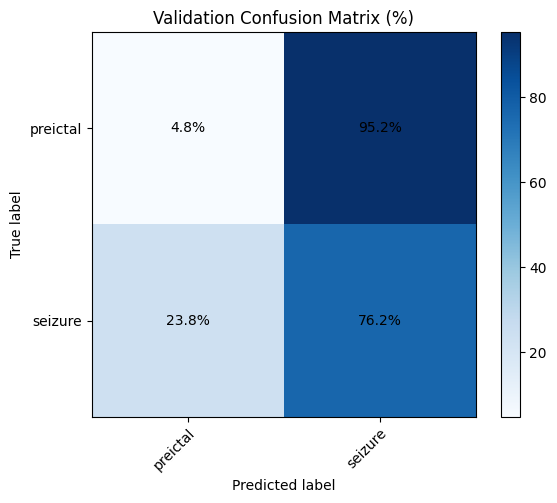

In [16]:
val_results = evaluate_and_plot(
    model=best_model_f1,
    X_data=X_val,
    y_true=y_val,
    class_names=class_names,
    dataset_name="Validation"
)

Se lee por filas: 

Preictal:
- 4.8% fueron correctamente clasificadas como preictal
- 95.2% fueron confundidas como seizure
  
Seizure:
- 23.8% fueron correctamente clasificadas como seizure
- 76.2% fueron confundidas como preictal


### 4.4 Test set evaluation


TEST SET

Classification table:
              precision    recall  f1-score    support
preictal       0.111111  0.037037  0.055556  27.000000
seizure        0.434783  0.714286  0.540541  28.000000
accuracy       0.381818  0.381818  0.381818   0.381818
macro avg      0.272947  0.375661  0.298048  55.000000
weighted avg   0.275889  0.381818  0.302457  55.000000

Global metrics:
Accuracy: 0.3818
Balanced accuracy: 0.3757
Macro F1: 0.2980


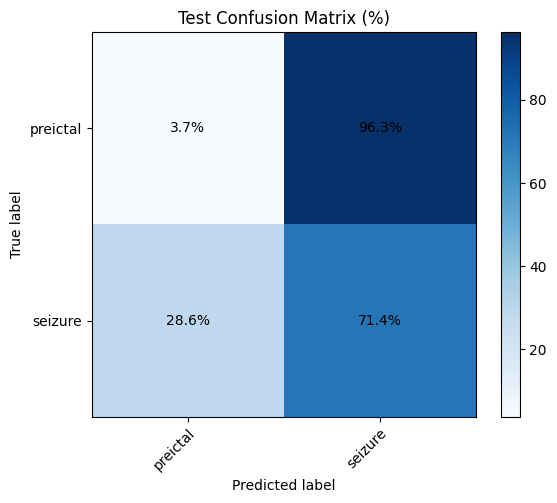

In [17]:
test_results = evaluate_and_plot(
    model=best_model_f1,
    X_data=X_test,
    y_true=y_test,
    class_names=class_names,
    dataset_name="Test"
)

## 4.3 Evaluate test set

In [19]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

# -----------------------------
# Evaluate final model on test set
# -----------------------------
y_test_pred = best_model_pca_svm.predict(X_test)

print("Test classification report:")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["preictal", "seizure"]
))

print("Test confusion matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("Test accuracy:", accuracy_score(y_test, y_test_pred))
print("Test balanced accuracy:", balanced_accuracy_score(y_test, y_test_pred))
print("Test macro F1:", f1_score(y_test, y_test_pred, average="macro"))
print("Test weighted F1:", f1_score(y_test, y_test_pred, average="weighted"))

print("Test precision macro:", precision_score(y_test, y_test_pred, average="macro"))
print("Test recall macro:", recall_score(y_test, y_test_pred, average="macro"))

NameError: name 'best_model_pca_svm' is not defined